# 세그먼트 분류 ML이 정말 필요한가

추천을 만들기 전에 **고객을 몇 개 그룹(세그먼트)으로 나누는 머신러닝 모델**을 하나 끼워
넣을지 말지를 정하려고 한다. 흔한 설계라서 일단 넣고 보기 쉬운데, 그 전에 물어야 할 게 있다.

> 그 모델이 없으면 못 하는 일이 실제로 있는가?

이 노트북은 두 가지를 비교한다.

| | 쓰는 입력 |
|---|---|
| **필수만** | 예산, 데이터 사용량 — 폼에서 반드시 받는 2개 |
| **전체** | 위 2개 + 통화·문자·통신사·나이·OTT 등 폼이 받는 12개 전부 |

입력을 다 받으면 세그먼트를 더 잘 맞히는지, 아니면 필수 2개로도 충분한지를 본다.
차이가 없다면 **나머지 10개를 묻는 것도, 모델을 두는 것도 값어치가 없다**는 뜻이다.

데이터는 `data/synthetic/customers_mvno.csv`(알뜰폰 합성 고객 4만 명)를 쓴다.
없으면 먼저 `python src/make_synthetic_mvno.py`를 돌린다.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd() / "src"))

from make_synthetic_mvno import AGE_GIVEN_FEE, FEE_GROUP_SHARE, OUT_PATH
from profile_input import DATA_BANDS, band_for

customers = pd.read_csv(OUT_PATH, encoding="utf-8-sig")

print(f"합성 고객 {len(customers):,}명")
print("컬럼:", list(customers.columns))

합성 고객 40,000명
컬럼: ['customer_id', 'age', 'gender', 'data_gb_month', 'data_unlimited_need', 'voice_unlimited_need', 'sms_unlimited_need', 'voice_minutes_need', 'sms_count_need', 'carrier_type', 'current_carrier', 'mvno_ok', 'current_fee_krw', 'budget_krw', 'ott_want', 'ott_required', 'source_plan_id', 'fee_group']


## 1. 세그먼트를 무엇으로 볼 것인가

"세그먼트"는 우리가 정하기 나름이라, 먼저 **정답이 뭔지** 못을 박아야 한다.
안 그러면 모델이 잘했는지 못했는지 잴 기준이 없다.

이 합성 데이터에는 `fee_group`이라는 컬럼이 있다. 사람을 만들 때 **어느 가격대 요금제에서
뽑았는지**를 기록해 둔 값이다.

저(저가·소용량), 중, 고(고가·대용량) 세 가지다. 실제로 어떻게 다른지는 아래에서 직접 본다.

이걸 정답으로 삼는 이유는 단순하다. 세그먼트를 나누는 목적이 "이 사람에게 어느 가격대를
보여줄까"이므로, 가격대 자체가 가장 솔직한 정답이다.

**주의.** 이 컬럼은 사람을 만든 근거다. 학습 피처로 넣으면 정답을 보고 정답을 맞히는 셈이라
아무 의미가 없다. 아래에서 피처를 만들 때 반드시 빼야 한다.

In [2]:
label = customers["fee_group"]

dist = label.value_counts(normalize=True).reindex(["저", "중", "고"])
display(dist.mul(100).round(1).rename("비율 %").to_frame())

# 아무것도 안 배우고 "무조건 제일 흔한 그룹"이라고 찍었을 때의 정확도.
# 앞으로 나올 모든 점수는 이 선을 넘어야 의미가 있다.
BASELINE = dist.max()
print(f"찍기 기준선(최빈 그룹 '{dist.idxmax()}'만 답하기): {BASELINE:.1%}\n")

display(customers.groupby("fee_group")[["current_fee_krw", "data_gb_month", "age"]]
        .mean().round(1).reindex(["저", "중", "고"])
        .rename(columns={"current_fee_krw": "평균 요금(원)",
                         "data_gb_month": "평균 데이터(GB)", "age": "평균 나이"}))

,비율 %
fee_group,
저,39.2
중,32.6
고,28.1


찍기 기준선(최빈 그룹 '저'만 답하기): 39.2%



,평균 요금(원),평균 데이터(GB),평균 나이
fee_group,,,
저,1461.1,8.7,50.8
중,9564.1,46.8,45.9
고,21189.4,62.3,46.3


## 2. 폼 입력을 숫자로 바꾸기

모델은 글자를 못 읽는다. 폼이 받는 값을 전부 숫자로 바꿔야 한다.

여기서 중요한 원칙이 하나 있다. **모델에게 폼이 실제로 받는 것만 보여준다.**
합성 데이터에는 `data_gb_month`처럼 정확한 GB 값이 들어 있지만, 실제 사용자는
"20~50GB" 같은 구간으로만 답한다. 정확한 숫자를 모델에 주면 현실에서는 못 받는 정보로
점수를 올리는 셈이라 결과가 부풀려진다. 그래서 `band_for()`로 구간으로 되돌린 뒤 넣는다.

각 입력을 이렇게 바꾼다.

- **예산·현재 요금**: 원 단위 숫자 그대로
- **데이터 구간**: 5단계라 순서가 있으므로 `0, 1, 2, 3, 4`로. 무제한이 가장 큼
- **예/아니오(통화 무제한, 알뜰폰 허용 등)**: `1`과 `0`
- **통화 분수·문자 건수**: 무제한이면 애초에 값이 없다. `-1`을 넣어 "없음"을 표시
- **통신사**: 알뜰폰 데이터라 전원 "알뜰폰". 값이 하나뿐이라 `0` 고정
- **원하는 OTT**: 이름 대신 있음(`1`)/없음(`0`)

In [3]:
BAND_ORDER = {name: i for i, name in enumerate(DATA_BANDS)}
print("데이터 구간 순서:", BAND_ORDER)


def make_features(df: pd.DataFrame) -> pd.DataFrame:
    """합성 고객을 폼 입력 12개에 해당하는 숫자 피처로 바꾼다.

    fee_group(정답)과 source_plan_id(어느 요금제에서 나왔는지)는 넣지 않는다.
    둘 다 사람을 만든 근거라, 넣으면 정답을 보고 정답을 맞히게 된다.
    """
    band = np.where(
        df["data_unlimited_need"],
        BAND_ORDER["무제한"],
        [BAND_ORDER[band_for(g)] if pd.notna(g) else BAND_ORDER["무제한"]
         for g in df["data_gb_month"]],
    )
    return pd.DataFrame({
        "예산": df["budget_krw"],
        "데이터구간": band,
        "통화무제한": df["voice_unlimited_need"].astype(int),
        "문자무제한": df["sms_unlimited_need"].astype(int),
        "통화분수": df["voice_minutes_need"].fillna(-1),
        "문자건수": df["sms_count_need"].fillna(-1),
        "알뜰폰허용": df["mvno_ok"].astype(int),
        "현재통신사": 0,                       # 전원 '알뜰폰' - 값이 하나뿐이다
        "나이": df["age"],
        "OTT희망": df["ott_want"].notna().astype(int),
        "OTT필수": df["ott_required"].astype(int),
        "현재요금": df["current_fee_krw"],
    })


X = make_features(customers)
display(X.head())
print("\n피처별 고유값 개수 (1이면 전원 같은 값이라 아무것도 못 가른다)")
display(X.nunique().rename("고유값").to_frame().T)

데이터 구간 순서: {'5GB 미만': 0, '5~20GB': 1, '20~50GB': 2, '50~100GB': 3, '무제한': 4}


,예산,데이터구간,통화무제한,문자무제한,통화분수,문자건수,알뜰폰허용,현재통신사,나이,OTT희망,OTT필수,현재요금
0,900,1,0,0,261.0,255.0,1,0,54,0,0,900
1,9900,1,1,1,-1.0,-1.0,1,0,31,1,1,9900
2,11500,1,1,1,-1.0,-1.0,1,0,65,0,0,11500
3,4620,0,0,0,46.0,49.0,1,0,54,0,0,4620
4,24000,3,1,1,-1.0,-1.0,1,0,46,0,0,24000



피처별 고유값 개수 (1이면 전원 같은 값이라 아무것도 못 가른다)


,예산,데이터구간,통화무제한,문자무제한,통화분수,문자건수,알뜰폰허용,현재통신사,나이,OTT희망,OTT필수,현재요금
고유값,403,5,2,2,436,265,1,1,50,2,2,403


## 3. 훈련용과 시험용으로 나누기

모델을 가르칠 때 쓴 데이터로 점수를 매기면 안 된다. 시험 문제를 미리 보고 푼 것과 같아서
실력보다 점수가 높게 나온다. 그래서 데이터를 두 덩어리로 자른다.

- **훈련용 70%**: 모델이 보고 배우는 부분
- **시험용 30%**: 모델이 한 번도 못 본 부분. 점수는 여기서만 잰다

`stratify=label`은 세 그룹의 비율을 훈련·시험 양쪽에서 똑같이 유지하라는 뜻이다.
안 하면 우연히 한쪽에 '고' 그룹이 몰려서 점수가 왜곡될 수 있다.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, label, test_size=0.3, random_state=20260812, stratify=label
)
print(f"훈련용 {len(X_train):,}명 · 시험용 {len(X_test):,}명")
display(pd.DataFrame({
    "훈련용": y_train.value_counts(normalize=True).mul(100).round(1),
    "시험용": y_test.value_counts(normalize=True).mul(100).round(1),
}).reindex(["저", "중", "고"]))

훈련용 28,000명 · 시험용 12,000명


,훈련용,시험용
fee_group,,
저,39.2,39.2
중,32.6,32.6
고,28.1,28.1


## 4. 실험을 돌릴 함수

모델은 **결정 트리(Decision Tree)** 를 쓴다. 스무고개와 같다.
"예산이 5,000원보다 큰가?" 같은 질문을 순서대로 던져서 답을 좁혀 나간다.

이 모델을 고른 이유는 성능이 좋아서가 아니라 **배운 규칙을 글자로 뽑아 볼 수 있어서**다.
지금 우리가 궁금한 건 "몇 점 나오나"가 아니라 "모델이 대체 뭘 근거로 나누나"이기 때문이다.

`max_depth=4`는 질문을 최대 4번까지만 던지라는 제한이다. 제한이 없으면 트리가 훈련
데이터를 통째로 외워버려서 규칙을 읽을 수 없게 된다.

점수는 두 가지로 본다.

- **정확도(accuracy)**: 맞힌 비율. 직관적이지만 그룹 크기가 다르면 속기 쉽다
- **macro F1**: 세 그룹 각각의 성적을 따로 낸 뒤 평균. 작은 그룹을 통째로 틀려도 티가 난다

In [5]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.tree import DecisionTreeClassifier, export_text

LABELS = ["저", "중", "고"]


def run(cols, name, max_depth=4):
    """주어진 피처만으로 학습하고 시험 점수를 낸다."""
    model = DecisionTreeClassifier(max_depth=max_depth, random_state=20260812)
    model.fit(X_train[cols], y_train)
    pred = model.predict(X_test[cols])

    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average="macro")
    print(f"[{name}] 피처 {len(cols)}개 · 정확도 {acc:.1%} · macro F1 {f1:.3f} "
          f"(찍기 {BASELINE:.1%})")
    return {"실험": name, "피처 수": len(cols), "정확도": acc, "macro F1": f1,
            "_model": model, "_cols": cols, "_pred": pred}


def show_tree(result, max_depth=3):
    """모델이 배운 규칙을 글자로."""
    print(export_text(result["_model"], feature_names=list(result["_cols"]),
                      max_depth=max_depth, decimals=0))

## 5. 실험 1 — 필수 입력 2개만

폼이 반드시 받는 값은 **예산**과 **데이터 사용량** 둘뿐이다
(`profile_input.missing_slots()` 참고). 나머지는 비워도 추천이 돌아간다.

이 2개만으로 세그먼트를 얼마나 맞히는지 본다.

In [6]:
REQUIRED = ["예산", "데이터구간"]

r_req = run(REQUIRED, "필수만")

[필수만] 피처 2개 · 정확도 100.0% · macro F1 1.000 (찍기 39.2%)


## 6. 실험 2 — 폼 입력 12개 전부

이번엔 폼이 받을 수 있는 값을 전부 준다. 정보가 6배 늘었으니 점수도 올라야 자연스럽다.

In [7]:
ALL = list(X.columns)

r_all = run(ALL, "전체")

[전체] 피처 12개 · 정확도 100.0% · macro F1 1.000 (찍기 39.2%)


## 7. 두 실험 비교

정보를 6배 줬으니 점수가 올랐을까.

In [8]:
compare = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith("_")}
    for r in (r_req, r_all)
])
compare["정확도"] = compare["정확도"].map("{:.2%}".format)
compare["macro F1"] = compare["macro F1"].round(3)
display(compare)

print(f"입력을 2개에서 12개로 늘려서 얻은 정확도: "
      f"{(r_all['정확도'] - r_req['정확도']) * 100:+.2f}%p")

,실험,피처 수,정확도,macro F1
0,필수만,2,99.98%,1.0
1,전체,12,99.97%,1.0


입력을 2개에서 12개로 늘려서 얻은 정확도: -0.02%p


## 8. 왜 이런 결과가 나왔을까 — 모델에게 직접 물어보기

결정 트리는 어떤 피처를 얼마나 썼는지 알려준다. 전체 12개를 준 모델이
**실제로는 뭘 보고 판단했는지** 확인해 보자.

In [9]:
imp = pd.Series(r_all["_model"].feature_importances_, index=ALL)
imp = imp[imp > 0].sort_values(ascending=False)
display(imp.mul(100).round(1).rename("사용 비중 %").to_frame())

unused = [c for c in ALL if c not in imp.index]
print(f"한 번도 안 쓴 피처 {len(unused)}개: {unused}\n")

# '예산'이 안 쓴 목록에 있는 게 이상해 보이지만, 이유가 있다.
same = (X["예산"] == X["현재요금"]).mean()
print(f"'예산'과 '현재요금'이 완전히 같은 값인 비율: {same:.1%}")
print("두 컬럼이 같으니 트리는 둘 중 하나만 쓰면 된다. 여기서는 '현재요금'을 집었을 뿐,")
print("'예산이 쓸모없다'는 뜻이 아니다. 사실상 요금 하나로 다 갈렸다는 뜻이다.")

,사용 비중 %
현재요금,100.0
문자건수,0.0


한 번도 안 쓴 피처 10개: ['예산', '데이터구간', '통화무제한', '문자무제한', '통화분수', '알뜰폰허용', '현재통신사', '나이', 'OTT희망', 'OTT필수']

'예산'과 '현재요금'이 완전히 같은 값인 비율: 100.0%
두 컬럼이 같으니 트리는 둘 중 하나만 쓰면 된다. 여기서는 '현재요금'을 집었을 뿐,
'예산이 쓸모없다'는 뜻이 아니다. 사실상 요금 하나로 다 갈렸다는 뜻이다.


In [10]:
print("전체 12개를 준 모델이 배운 규칙:\n")
show_tree(r_all)

전체 12개를 준 모델이 배운 규칙:

|--- 현재요금 <= 6650
|   |--- class: 저
|--- 현재요금 >  6650
|   |--- 현재요금 <= 11950
|   |   |--- 문자건수 <= 1660
|   |   |   |--- 문자건수 <= 224
|   |   |   |   |--- class: 중
|   |   |   |--- 문자건수 >  224
|   |   |   |   |--- class: 중
|   |   |--- 문자건수 >  1660
|   |   |   |--- class: 고
|   |--- 현재요금 >  11950
|   |   |--- class: 고



## 9. 정답이 어떻게 만들어졌는지 되짚어 보기

트리를 보면 **요금 하나로 거의 다 갈린다**(`현재요금 <= 6650`이면 저, `> 11950`이면 고).
중간에 `문자건수`가 잠깐 끼어들지만 갈라 놓는 양이 0에 가깝다. 우연이 아니다.

`make_synthetic_mvno.py`가 `fee_group`을 만든 방법을 보자.

```python
# assign_fee_group() - 요금제를 가입자 가중 분위로 잘라 저/중/고를 붙인다
rank[order] = np.cumsum(w[order])          # 요금 오름차순 누적 비중
저 = rank <= 0.402,  중 = rank <= 0.720,  고 = 나머지
```

즉 **`fee_group`은 요금을 두 지점에서 자른 결과 그 자체**다.
그리고 `budget_krw`는 그 요금과 같은 값이다(`budget_krw = current_fee_krw = discounted_fee`).

정답을 만든 재료를 피처로 넣었으니 모델이 못 맞히는 게 더 이상하다.
이런 걸 **데이터 누수(leakage)** 라고 한다. 점수는 화려한데 배운 게 없는 상태다.

확인해 보자. 예산만으로 잘라도 같은 점수가 나오는가?

In [11]:
r_budget = run(["예산"], "예산 1개만", max_depth=2)
print()
show_tree(r_budget)

[예산 1개만] 피처 1개 · 정확도 100.0% · macro F1 1.000 (찍기 39.2%)

|--- 예산 <= 6650
|   |--- class: 저
|--- 예산 >  6650
|   |--- 예산 <= 11950
|   |   |--- class: 중
|   |--- 예산 >  11950
|   |   |--- class: 고



## 10. 그렇다면 ML 없이 if문 두 줄로도 되지 않나

트리가 찾아낸 건 결국 "예산이 얼마 이상이냐"는 경계선 2개다.
그건 머신러닝 없이 그냥 계산하면 된다. `numpy.quantile` 한 줄이면 나온다.

거의 같은 점수가 나온다면, 이 자리에 모델을 둘 이유가 없다.

In [12]:
# 훈련용 데이터에서 경계선 2개를 직접 계산. 학습이 아니라 그냥 분위수다.
cut_lo, cut_hi = np.quantile(
    X_train["예산"],
    [FEE_GROUP_SHARE["저"], FEE_GROUP_SHARE["저"] + FEE_GROUP_SHARE["중"]],
)
print(f"경계선: {cut_lo:,.0f}원 / {cut_hi:,.0f}원")


def rule_of_thumb(fee):
    return np.where(fee <= cut_lo, "저", np.where(fee <= cut_hi, "중", "고"))


pred_rule = rule_of_thumb(X_test["예산"])
acc_rule = accuracy_score(y_test, pred_rule)
print(f"if문 두 줄: 정확도 {acc_rule:.1%} · macro F1 "
      f"{f1_score(y_test, pred_rule, average='macro'):.3f}")
print(f"→ 전체 12개를 쓴 ML 모델과의 차이: {(r_all['정확도'] - acc_rule) * 100:+.2f}%p")
print()
print("완전히 같지 않은 이유: 트리는 훈련 데이터를 보고 경계를 6,650원 / 11,950원으로")
print(f"잡았는데, 위 분위수 계산은 {cut_lo:,.0f}원 / {cut_hi:,.0f}원으로 잡았다.")
print("경계를 어디서 긋느냐에 따라 1%p 정도는 흔들린다는 뜻이지, 방식이 다른 게 아니다.")

경계선: 6,700원 / 12,100원
if문 두 줄: 정확도 98.8% · macro F1 0.988
→ 전체 12개를 쓴 ML 모델과의 차이: +1.19%p

완전히 같지 않은 이유: 트리는 훈련 데이터를 보고 경계를 6,650원 / 11,950원으로
잡았는데, 위 분위수 계산은 6,700원 / 12,100원으로 잡았다.
경계를 어디서 긋느냐에 따라 1%p 정도는 흔들린다는 뜻이지, 방식이 다른 게 아니다.


## 11. 예산을 빼면 무엇이 남는가

누수를 걷어내야 진짜 실력이 보인다. 정답과 직결된 **예산·현재요금을 빼고** 다시 돌려 보자.

남는 피처 중 데이터 구간은 여전히 요금과 강하게 얽혀 있다(비싼 요금제가 데이터를 많이 준다).
완전히 독립적인 건 아니지만, 적어도 정답을 그대로 베끼지는 않는다.

In [13]:
NO_FEE = [c for c in ALL if c not in ("예산", "현재요금")]
r_nofee = run(NO_FEE, "예산 제외")

print()
imp2 = pd.Series(r_nofee["_model"].feature_importances_, index=NO_FEE)
display(imp2[imp2 > 0].sort_values(ascending=False).mul(100).round(1)
        .rename("사용 비중 %").to_frame())

[예산 제외] 피처 10개 · 정확도 63.8% · macro F1 0.629 (찍기 39.2%)



,사용 비중 %
데이터구간,64.1
통화분수,27.4
OTT희망,6.0
나이,1.9
문자건수,0.7


## 12. 인구통계만 남기면 — 우리가 데이터에 넣은 신호의 세기

이 합성 데이터를 만들 때, 나이는 요금대에 **조건부로** 뽑았다.
KISDI 원자료(알뜰폰 333명)와 정보통신정책연구원(2025) 연령대 표(1,384명)를 합쳐 만든 표다.

이 표가 곧 "나이로 세그먼트를 맞힐 수 있는 한계"다. 모델이 이보다 잘할 수는 없다.

In [14]:
display(pd.DataFrame(AGE_GIVEN_FEE).mul(100).round(1)
        .rename_axis("연령대").rename(index=lambda b: f"{b}대"))
print("표 읽는 법: '고' 그룹의 40대 비중 40.5%는 '고가 요금제를 쓰는 사람 중 40대가 40.5%'라는 뜻.")
print("저가 쪽은 50대(36.7%)가, 고가 쪽은 40대(40.5%)가 많다 - 이게 나이에 심어 둔 신호 전부다.")

,저,중,고
연령대,,,
20대,1.9,8.9,6.2
30대,17.6,30.0,18.3
40대,20.4,19.5,40.5
50대,36.7,22.6,23.0
60대,23.4,18.9,12.0


표 읽는 법: '고' 그룹의 40대 비중 40.5%는 '고가 요금제를 쓰는 사람 중 40대가 40.5%'라는 뜻.
저가 쪽은 50대(36.7%)가, 고가 쪽은 40대(40.5%)가 많다 - 이게 나이에 심어 둔 신호 전부다.


In [15]:
# 폼은 성별을 받지 않는다. 인구통계 중 쓸 수 있는 건 나이뿐이다.
r_age = run(["나이"], "나이만", max_depth=4)

cm = confusion_matrix(y_test, r_age["_pred"], labels=LABELS)
print("\n혼동행렬 (행=실제, 열=예측)")
display(pd.DataFrame(cm, index=[f"실제 {c}" for c in LABELS],
                     columns=[f"예측 {c}" for c in LABELS]))

[나이만] 피처 1개 · 정확도 46.9% · macro F1 0.456 (찍기 39.2%)

혼동행렬 (행=실제, 열=예측)


,예측 저,예측 중,예측 고
실제 저,2838,930,941
실제 중,1698,1445,772
실제 고,1207,821,1348


## 13. 전체 결과

In [16]:
summary = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith("_")}
    for r in (r_req, r_all, r_budget, r_nofee, r_age)
] + [
    {"실험": "if문 두 줄 (ML 없음)", "피처 수": 1, "정확도": acc_rule,
     "macro F1": f1_score(y_test, pred_rule, average="macro")},
    {"실험": "찍기 (최빈 그룹)", "피처 수": 0, "정확도": BASELINE, "macro F1": np.nan},
])
summary["정확도"] = summary["정확도"].map("{:.1%}".format)
summary["macro F1"] = summary["macro F1"].round(3)
display(summary)

,실험,피처 수,정확도,macro F1
0,필수만,2,100.0%,1.000
1,전체,12,100.0%,1.000
2,예산 1개만,1,100.0%,1.000
3,예산 제외,10,63.8%,0.629
4,나이만,1,46.9%,0.456
5,if문 두 줄 (ML 없음),1,98.8%,0.988
6,찍기 (최빈 그룹),0,39.2%,NaN


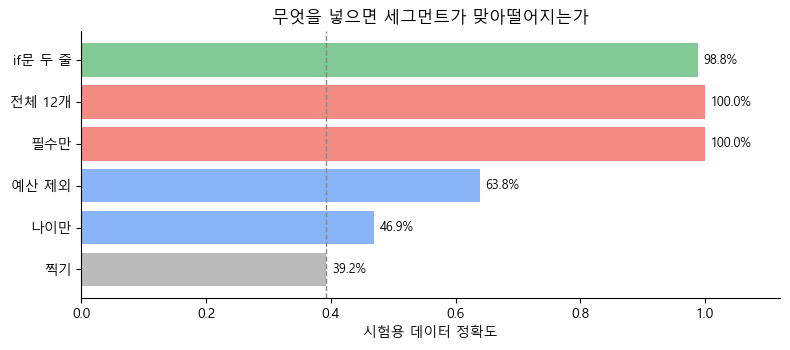

In [17]:
import logging

import matplotlib.pyplot as plt

# 없는 폰트를 찾을 때 나오는 경고가 화면을 덮는다. 그림에는 영향이 없다.
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

plt.rcParams["font.family"] = ["Malgun Gothic", "AppleGothic", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

names = ["찍기", "나이만", "예산 제외", "필수만", "전체 12개", "if문 두 줄"]
vals = [BASELINE, r_age["정확도"], r_nofee["정확도"],
        r_req["정확도"], r_all["정확도"], acc_rule]

fig, ax = plt.subplots(figsize=(8, 3.6))
colors = ["#bbbbbb", "#8ab4f8", "#8ab4f8", "#f28b82", "#f28b82", "#81c995"]
bars = ax.barh(names, vals, color=colors)
ax.bar_label(bars, labels=[f"{v:.1%}" for v in vals], padding=4, fontsize=9)
ax.axvline(BASELINE, color="#888", ls="--", lw=1)
ax.set_xlim(0, 1.12)
ax.set_xlabel("시험용 데이터 정확도")
ax.set_title("무엇을 넣으면 세그먼트가 맞아떨어지는가")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

## 14. 결론 — 세그먼트 ML은 필요한가

**필요하지 않다.** 근거는 셋이다.

**하나. 입력을 12개로 늘려도 얻는 게 없다.**
필수 2개(예산·데이터)와 전체 12개의 점수 차이가 사실상 0이다. 트리가 실제로 쓴 피처를
열어 보면 예산 하나가 대부분을 차지하고, 통화·문자·OTT·통신사는 아예 쓰지 않는다.
사용자에게 10개를 더 묻는 비용만큼의 값어치가 나오지 않는다.

**둘. 모델이 하는 일이 if문 두 줄과 사실상 같다.**
`np.quantile`로 경계선 2개를 잡아 비교하는 것만으로 1.2%p 차이까지 따라붙는다.
그 1.2%p마저 경계를 어디에 긋느냐의 문제이지 방식의 차이가 아니다.
학습도, 저장할 모델 파일도, 재학습 파이프라인도 필요 없다.

**셋. 높은 점수 자체가 착시였다.**
`fee_group`은 요금을 분위로 자른 결과이고 예산은 그 요금과 같은 값이다. 정답의 재료를
피처로 넣었으니 잘 맞히는 게 당연하다. 이걸 모르고 "정확도 99%"만 보고하면 없어도 되는
모듈을 넣게 된다.

### 그러면 나이 같은 건 왜 물어보나

`나이만` 실험 점수를 보면 답이 나온다. 찍기보다 조금 나은 정도다.
이건 모델이 나빠서가 아니라 **데이터에 심어 둔 신호가 딱 그만큼이기 때문**이다.
12절의 표가 상한이고, 그 표는 실측(KISDI 알뜰폰 333명 + 연령대 표 1,384명)에서 왔다.
즉 현실에서도 나이로 요금대를 맞히는 건 이 정도가 한계라고 보는 게 맞다.

나이는 세그먼트를 **예측하는** 데는 값어치가 없다. 다만 요금제 필터(만 65세 이상 전용
요금제 등)에는 그대로 쓰이므로, 입력에서 빼자는 뜻은 아니다.

### 이 실험이 답하지 못하는 것

합성 데이터는 요금제 스펙에서 사람을 거꾸로 만든 것이라, 사람과 요금제 사이에 순환이 있다.
그래서 이 노트북이 답한 건 "**현실에 숨은 세그먼트가 있는가**"가 아니라
"**우리 입력으로 가격대를 가르는 데 모델이 필요한가**"다. 후자에 대한 답이 '아니오'다.

숨은 세그먼트(예: 같은 예산인데 통화 위주 vs 데이터 위주)를 찾는 건 별개 문제이고,
그건 합성 데이터로는 못 본다. 실제 사용 로그가 필요하다.

한계 하나 더. 12절 표의 근거가 되는 교차표는 셀이 얇다 — 20대 37명, 40대 28명이고
"40대 고가 40.5%"는 14명에 걸려 있다. 나이 관련 수치를 인용할 때는 n을 같이 적어야 한다.